# A/B-тест рекомендательного алгоритма в развлекательном приложении

**Тема: «Анализ результатов
A/B-тестирования».** Продукт запустил A/B-тест нового алгоритма рекомендаций. Целевая
метрика — доля **успешных первых сессий** (пользователь просмотрел ≥ 4 страниц).
Задача: проверить, вырос ли этот показатель в тестовой группе, и дать рекомендацию.

Полный цикл: **дизайн эксперимента** (размер выборки, MDE, длительность) →
**проверка корректности сплита** → **проверка значимости** (Z-тест пропорций) →
дополнительные техники (t-тест, тест Манна-Уитни).

**Данные** — реальные датасеты проекта, публично размещённые на S3
(читаются по ссылке ниже, ничего скачивать вручную не нужно):
`sessions_project_history.csv` (история до теста), `sessions_project_test_part.csv`
(первый день теста, для проверки сплита), `sessions_project_test.csv` (весь период теста).

**Стек:** `pandas`, `numpy`, `scipy.stats`, `statsmodels`, `matplotlib`.


## 0. Импорты и загрузка данных

In [1]:
import pandas as pd
import numpy as np
from math import ceil
from scipy.stats import ttest_ind, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import NormalIndPower
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (9, 4)

BASE = 'https://code.s3.yandex.net/datasets/'
sessions_history   = pd.read_csv(BASE + 'sessions_project_history.csv')   # до теста
sessions_test_part = pd.read_csv(BASE + 'sessions_project_test_part.csv') # первый день теста
sessions_test      = pd.read_csv(BASE + 'sessions_project_test.csv')      # весь период теста

print('history:', sessions_history.shape,
      '| test_part:', sessions_test_part.shape,
      '| test:', sessions_test.shape)
sessions_test.head()

history: (435924, 10) | test_part: (3130, 11) | test: (100005, 11)


,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B


**Поля.** `user_id`, `session_id`, `session_date`, `session_start_ts` (метка времени начала),
`install_date`, `session_number` (номер сессии пользователя), `registration_flag`,
`page_counter` (просмотрено страниц), `region`, `device`, `test_group` (A / B).

## 1. Исследование целевой метрики

Успешная первая сессия — первая сессия пользователя (`session_number == 1`),
в которой открыто **≥ 4 страниц**. Посмотрим на распределение числа страниц в первых сессиях.

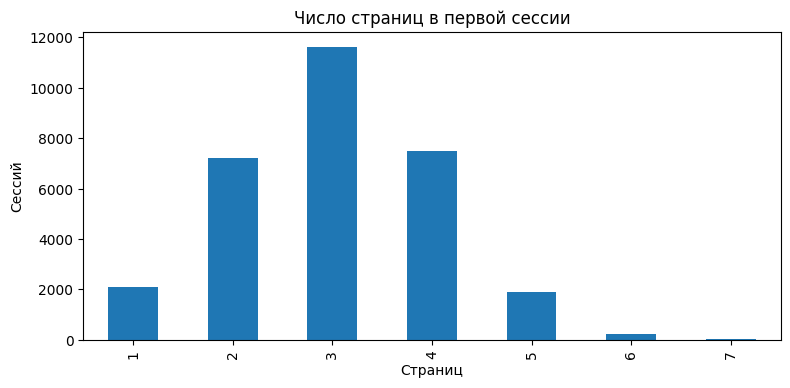

{1: 2084, 2: 7220, 3: 11636, 4: 7481, 5: 1881, 6: 232, 7: 44}
Доля первых сессий с >= 4 страниц: 31.52 %


In [2]:
first_all = sessions_test[sessions_test['session_number'] == 1]
pages = first_all['page_counter'].value_counts().sort_index()
pages.plot(kind='bar', title='Число страниц в первой сессии'); plt.xlabel('Страниц'); plt.ylabel('Сессий'); plt.show()
print(pages.to_dict())
print('Доля первых сессий с >= 4 страниц: {:.2f} %'.format((first_all['page_counter'] >= 4).mean() * 100))

Порог в 4 страницы отсекает верхнюю треть распределения — успешными оказываются ≈ 31.5 % первых сессий. Это и есть базовая конверсия для дизайна теста.

## 2. Дизайн эксперимента

### 2.1 Размер выборки
α = 0.05, мощность = 0.8, базовая конверсия p = 0.30, **MDE = 3 % относительно** p.
Частая ошибка — принять MDE за 3 процентных пункта; правильно `mde = p * 0.03`.

In [3]:
alpha, power, p = 0.05, 0.8, 0.30
mde = p * 0.03                                   # относительный MDE, не 3 п.п.!
effect_size = proportion_effectsize(p, p + mde)
sample_size = ceil(NormalIndPower().solve_power(effect_size=effect_size,
                                                power=power, alpha=alpha, ratio=1))
print(f'MDE (относит. 3%): {mde:.4f}  ->  {p:.2f} -> {p + mde:.3f}')
print(f'Нужный размер выборки: {sample_size} пользователей на группу')

MDE (относит. 3%): 0.0090  ->  0.30 -> 0.309
Нужный размер выборки: 41041 пользователей на группу


При относительном MDE 3 % нужно **≈ 41 040** пользователей на группу. Если бы MDE
ошибочно взяли как 3 п.п. (0.03 абсолютно), выборка была бы ~3.8 тыс. — почти в 11 раз
меньше, и тест недооценил бы нужный объём.

### 2.2 Длительность теста

In [4]:
avg_daily_users = sessions_history.groupby('session_date')['user_id'].nunique().mean()
test_duration = ceil(2 * sample_size / avg_daily_users)   # 2 группы
print(f'Средний дневной трафик (история): {avg_daily_users:.0f} польз./день')
print(f'Длительность теста: {test_duration} дней')

Средний дневной трафик (история): 9907 польз./день
Длительность теста: 9 дней


При среднем трафике ≈ 9 900 польз./день двум группам по 41 040 нужно ≈ **9 дней**.

## 3. Проверка корректности сплита

По первому дню теста (`sessions_test_part`): группы должны быть сопоставимы по размеру и не пересекаться по пользователям.

In [5]:
split = sessions_test_part.groupby('test_group')['user_id'].nunique()
diff = abs(split['A'] - split['B']) / split.mean() * 100
overlap = set(sessions_test_part[sessions_test_part.test_group == 'A']['user_id']) & \
          set(sessions_test_part[sessions_test_part.test_group == 'B']['user_id'])
print('Пользователей: A =', split['A'], '| B =', split['B'])
print(f'Разница в размере групп: {diff:.2f} %')
print('Пересечение A∩B:', len(overlap))

Пользователей: A = 1477 | B = 1466
Разница в размере групп: 0.75 %
Пересечение A∩B: 0


Разница групп < 1 %, пересечений нет — сплит корректен, можно анализировать результат.

## 4. Проверка значимости: Z-тест пропорций

`good_session` = первая сессия с `page_counter >= 4`. Считаем долю успешных первых сессий по группам за весь период теста.

In [6]:
sessions_test['good_session'] = (sessions_test['page_counter'] >= 4).astype(int)
first = sessions_test[sessions_test['session_number'] == 1]
conv = first.groupby('test_group')['good_session'].agg(['sum', 'count'])
conv['rate'] = conv['sum'] / conv['count']
print(conv)
print('\nРазница долей (B - A): {:+.2f} п.п.'.format((conv.loc['B','rate'] - conv.loc['A','rate']) * 100))

             sum  count      rate
test_group                       
A           4787  15162  0.315724
B           4851  15416  0.314673

Разница долей (B - A): -0.11 п.п.


### Динамика доли успешных первых сессий по дням

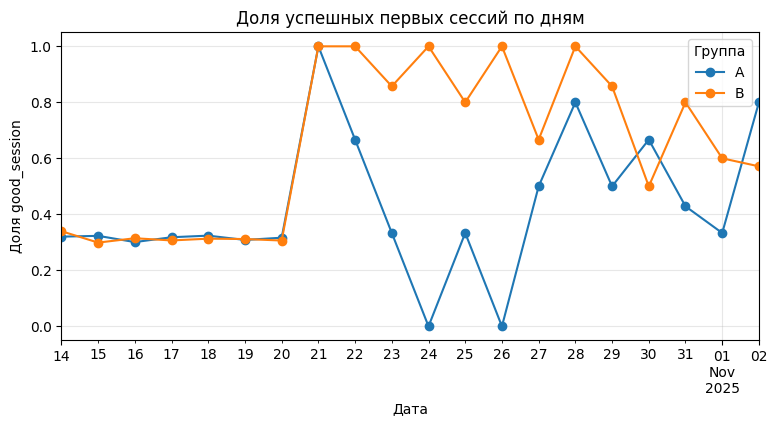

In [7]:
first = first.copy()
first['session_date'] = pd.to_datetime(first['session_date'])
daily = first.groupby(['session_date', 'test_group'])['good_session'].mean().unstack()
daily.plot(marker='o', title='Доля успешных первых сессий по дням')
plt.ylabel('Доля good_session'); plt.xlabel('Дата'); plt.legend(title='Группа'); plt.grid(alpha=.3); plt.show()

Линии A и B идут вплотную без устойчивого расхождения — визуально прироста в группе B не видно.

### Z-тест
- H₀: доля успешных первых сессий одинакова в A и B.
- H₁: в группе B (новый алгоритм) доля **выше** → `alternative='larger'`.

Сначала проверяем предпосылку достаточности данных `n·p ≥ 5` и `n·(1-p) ≥ 5`.

In [8]:
s_a, n_a = conv.loc['A', 'sum'], conv.loc['A', 'count']
s_b, n_b = conv.loc['B', 'sum'], conv.loc['B', 'count']
p_a, p_b = s_a / n_a, s_b / n_b
ok = all(x >= 5 for x in [n_a*p_a, n_a*(1-p_a), n_b*p_b, n_b*(1-p_b)])
print('Предпосылка достаточности данных выполняется!' if ok else 'Предпосылка НЕ выполняется!')

alpha = 0.05
stat, pval = proportions_ztest([s_b, s_a], [n_b, n_a], alternative='larger')
print(f'Z = {stat:.4f}, p-value = {pval:.4f}')
print('Отвергаем H0: прирост значим' if pval < alpha else 'Не удалось отвергнуть H0: прироста нет')

Предпосылка достаточности данных выполняется!
Z = -0.1977, p-value = 0.5784
Не удалось отвергнуть H0: прироста нет


**Вывод.** p-value ≈ 0.58 ≫ 0.05 → **не отвергаем H₀**. Статистически значимого прироста
доли успешных первых сессий у нового алгоритма нет.

## 5. Дополнительные техники сравнения групп

Дополнительно разбираю ещё два теста — показываю их на тех же данных.

### 5.1 t-тест Стьюдента — среднее число страниц за сессию
Сравнение средних двух независимых выборок. H₁: в B страниц больше (`alternative='greater'`).

In [9]:
m_a = sessions_test[sessions_test.test_group == 'A']['page_counter']
m_b = sessions_test[sessions_test.test_group == 'B']['page_counter']
stat, pval = ttest_ind(m_a, m_b, alternative='greater')
print(f'Среднее страниц: A = {m_a.mean():.3f}, B = {m_b.mean():.3f}')
print(f'p-value = {pval:.4f} -> ' + ('различие значимо' if pval < 0.05 else 'различий нет'))

Среднее страниц: A = 3.006, B = 3.041
p-value = 1.0000 -> различий нет


### 5.2 Тест Манна-Уитни — час начала сессии
Непараметрический тест на рангах, не требует нормальности. Сравним час начала сессий
двух групп (двусторонний, α = 0.10).

In [10]:
sessions_test['hour'] = pd.to_datetime(sessions_test['session_start_ts']).dt.hour
h_a = sessions_test[sessions_test.test_group == 'A']['hour']
h_b = sessions_test[sessions_test.test_group == 'B']['hour']
stat, pval = mannwhitneyu(h_a, h_b, alternative='two-sided')
print(f'p-value = {pval:.4f} -> ' + ('распределения различаются' if pval < 0.10 else 'распределения не различаются'))

p-value = 0.1364 -> распределения не различаются


## Итоги

- **Дизайн.** При α = 0.05, мощности 0.8 и относительном MDE 3 % нужно ≈ 41 тыс.
  пользователей на группу и ≈ 9 дней теста. Ключевой момент — MDE берётся **относительно**
  базовой конверсии (`p * 0.03`), а не в процентных пунктах.
- **Сплит** корректен: группы сопоставимы (разница < 1 %), пересечений нет.
- **Значимость.** Z-тест пропорций не выявил прироста доли успешных первых сессий
  (p ≈ 0.58). t-тест и тест Манна-Уитни различий между группами тоже не показали.
- **Бизнес-решение.** Новый алгоритм рекомендаций **не даёт статистически значимого
  улучшения** целевой метрики → внедрять не рекомендуется.

**Разобранные инструменты:** расчёт размера выборки и MDE (`statsmodels.power`),
проверка сплита, Z-тест пропорций, t-тест Стьюдента, тест Манна-Уитни.
